# Template 04a: PCA Feature Engineering

**Inputs:** data/02_conditioned.parquet
**Outputs:** data/04a_pca_features.parquet

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_coll/v1"


In [3]:
import matplotlib
matplotlib.use('Agg')
import pandas as pd
import yaml
import os
import sys
from pathlib import Path
from IPython.display import Image, display
sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment
from pca_utils import apply_pca_groups, create_scree_plot, create_loadings_heatmap, save_pca_summary
print('STAGE 04a: PCA FEATURE ENGINEERING')
project_root = setup_notebook_environment()

STAGE 04a: PCA FEATURE ENGINEERING


In [4]:
config_file = f'{config_path}/config.yaml'
with open(config_file, 'r') as f:
    cfg = yaml.safe_load(f)
output_base = cfg['paths']['output_base']
pca_cfg = cfg.get('feature_engineering', {}).get('pca', {})
pca_enabled = pca_cfg.get('enabled', False)
print(f'Output: {output_base}')
print(f'PCA Enabled: {pca_enabled}')

Output: output/car_coll/v1
PCA Enabled: True


In [5]:
plots_dir = f'{output_base}/plots'
results_dir = f'{output_base}/results'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

In [6]:
checkpoint_02 = f'{output_base}/data/02_conditioned.parquet'
data = pd.read_parquet(checkpoint_02)
print(f'Loaded: {data.shape}')
join_key = cfg['data']['join_key']
if join_key not in data.columns:
    raise ValueError(f'Join key not found')
print(f'Join key validated')

Loaded: (5424070, 112)
Join key validated


In [7]:
if not pca_enabled:
    print('PCA DISABLED - creating empty output')
    pca_output = data[[join_key]].copy()
    output_file = f'{output_base}/data/04a_pca_features.parquet'
    pca_output.to_parquet(output_file, index=False)
    print(f'Saved: {output_file}')
    raise SystemExit(0)

In [8]:
pca_results, all_pca_features = apply_pca_groups(data, pca_cfg, config_path)
print(f'Total PCA features: {all_pca_features.shape[1]}')


Applying PCA to 2 groups...
  Max components per group: 5

PCA Group: veh_char


  Input columns: 95
  Components kept: 5
  Cumulative variance: 51.9%
  New features: pca_veh_char_0, pca_veh_char_1, pca_veh_char_2, pca_veh_char_3, pca_veh_char_4

PCA Group: veh_hist


  Input columns: 8
  Components kept: 5
  Cumulative variance: 96.4%
  New features: pca_veh_hist_0, pca_veh_hist_1, pca_veh_hist_2, pca_veh_hist_3, pca_veh_hist_4

PCA complete: 10 features
Total PCA features: 10


In [9]:
print('GENERATING PLOTS')
plot_files = {}
for group in pca_results.keys():
    scree_path = create_scree_plot(pca_results[group], plots_dir, group)
    loadings_path = create_loadings_heatmap(pca_results[group], plots_dir, group)
    plot_files[group] = {'scree': scree_path, 'loadings': loadings_path}
    print(f'Created plots for {group}')

GENERATING PLOTS


Created plots for veh_char


Created plots for veh_hist


DISPLAYING PLOTS
PCA Group: veh_char


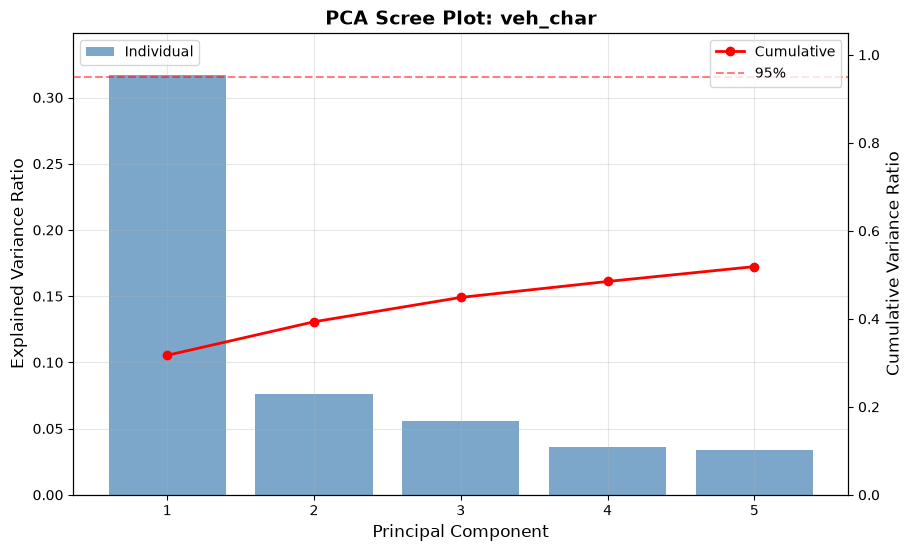

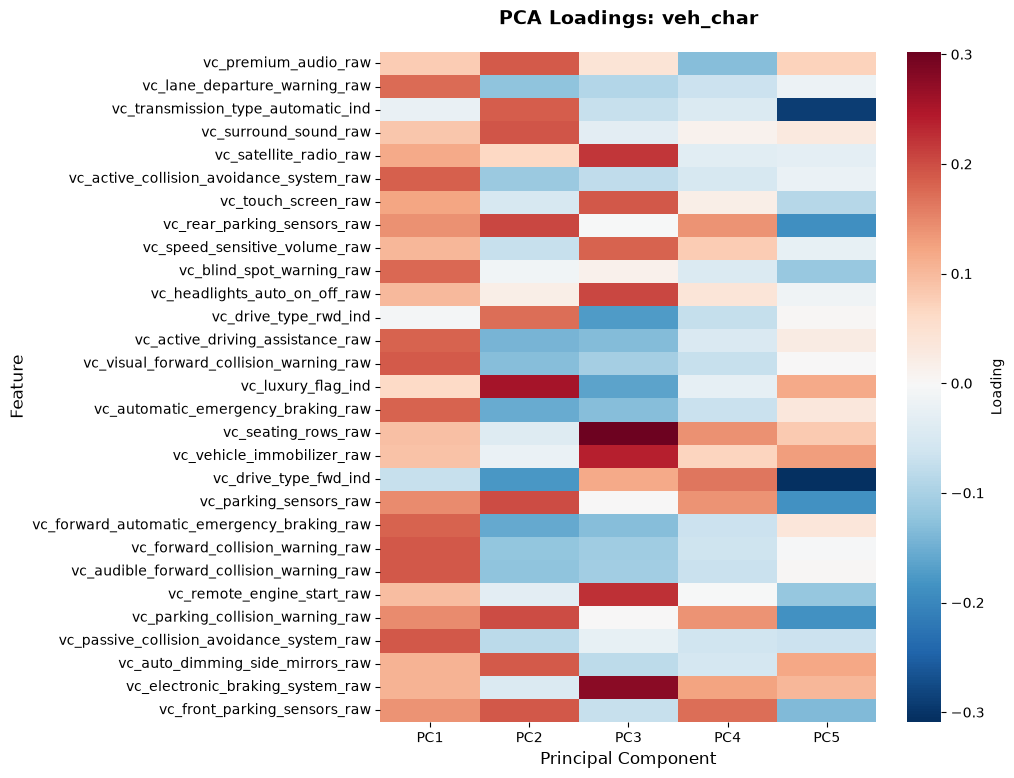

PCA Group: veh_hist


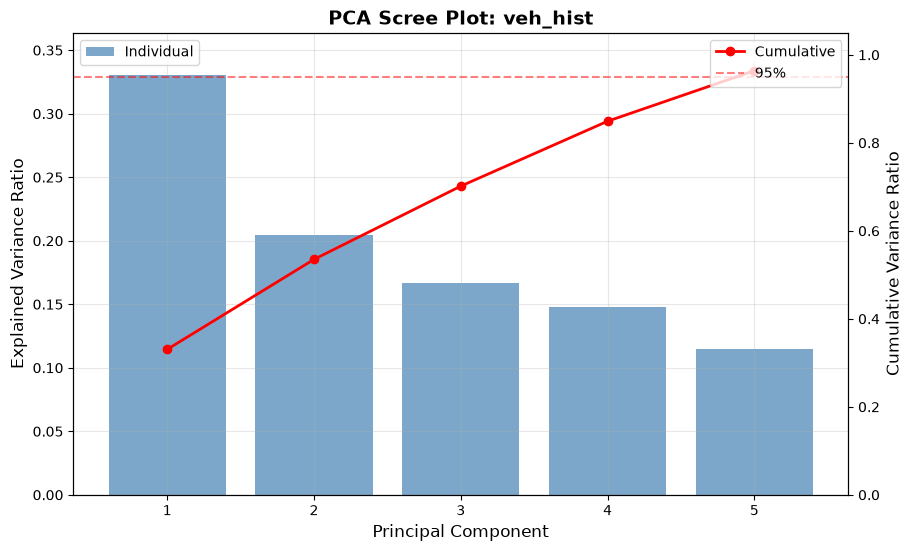

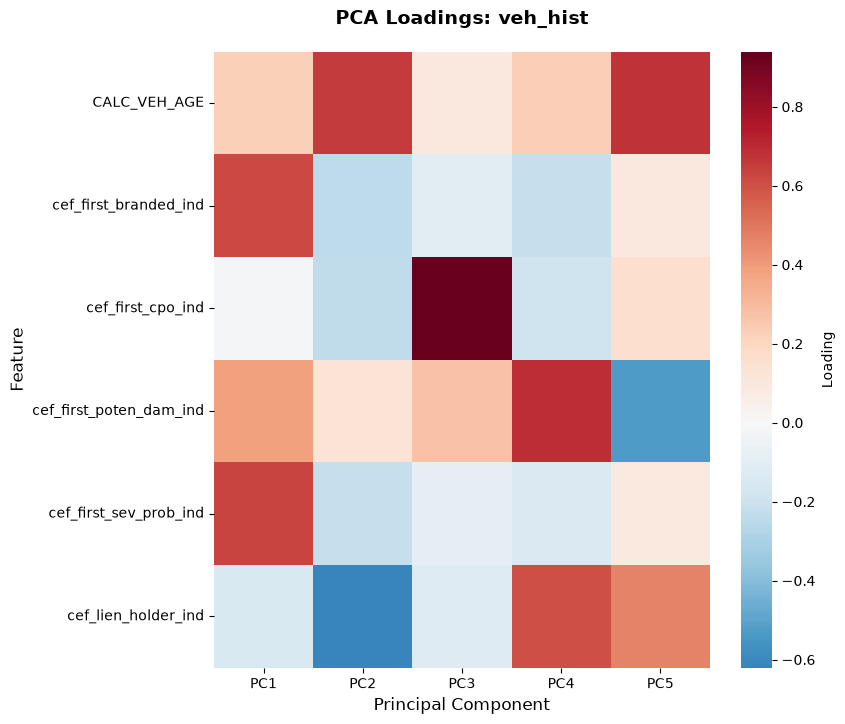

In [10]:
print('DISPLAYING PLOTS')
for group, paths in plot_files.items():
    print(f'PCA Group: {group}')
    display(Image(filename=paths['scree']))
    display(Image(filename=paths['loadings']))

In [11]:
pca_output = pd.DataFrame({join_key: data[join_key]})
pca_output = pd.concat([pca_output, all_pca_features], axis=1)
output_file = f'{output_base}/data/04a_pca_features.parquet'
pca_output.to_parquet(output_file, index=False)
print(f'Saved: {output_file}')
print(f'Shape: {pca_output.shape}')

Saved: output/car_coll/v1/data/04a_pca_features.parquet
Shape: (5424070, 11)


In [12]:
summary_file = save_pca_summary(pca_results, results_dir)
print(f'Summary saved: {summary_file}')

Summary saved: output/car_coll/v1/results/04a_pca_summary.yaml


In [13]:
print('STAGE 04a: COMPLETE')
print(f'PCA Groups: {len(pca_results)}')
print(f'Total Features: {all_pca_features.shape[1]}')

STAGE 04a: COMPLETE
PCA Groups: 2
Total Features: 10
